# Student Performance EDA for a County Education Office

## PLP Data Analytics Assignment 5

**Project:** Student Performance Exploratory Data Analysis  
**Dataset:** student_performance.csv  
**Sample size:** 1,200 students  
**Random seed:** 55

### Objective

This exploratory data analysis examines student performance and identifies learner characteristics and factors associated with stronger or weaker academic outcomes. The analysis focuses on attendance, study hours, gender, school type and county to provide evidence that can support targeting decisions for a learner-support programme.

# 1. Structure

This section examines the grain of the dataset, variables, data types, dimensions and data quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("student_performance.csv")

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (1200, 9)

First five rows:


,student_id,gender,school_type,county,attendance,study_hours,math_score,english_score,science_score
0,1,Female,Private,Mombasa,62.1,14.3,57.6,70.2,68.6
1,2,Male,Public,Nairobi,91.1,7.8,45.0,62.6,63.0
2,3,Female,Public,Kisumu,85.0,13.0,71.4,56.6,71.6
3,4,Female,Public,Laikipia,86.5,7.0,50.2,57.7,43.9
4,5,Male,Private,Nairobi,75.4,14.5,63.8,71.7,71.7



Data types:


student_id         int64
gender               str
school_type          str
county               str
attendance       float64
study_hours      float64
math_score       float64
english_score    float64
science_score    float64
dtype: object


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   student_id     1200 non-null   int64  
 1   gender         1200 non-null   str    
 2   school_type    1200 non-null   str    
 3   county         1200 non-null   str    
 4   attendance     1200 non-null   float64
 5   study_hours    1200 non-null   float64
 6   math_score     1200 non-null   float64
 7   english_score  1200 non-null   float64
 8   science_score  1200 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 84.5 KB


## Grain of the data

The grain of this dataset is **one row per student**. Each observation represents one learner and contains demographic, school, attendance, study-hour and subject-performance information.

In [2]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate student IDs:", df["student_id"].duplicated().sum())

print("\nUnique values per column:")
display(df.nunique())

print("\nNumerical summary:")
display(df.describe())

Number of rows: 1200
Number of columns: 9

Missing values:


student_id       0
gender           0
school_type      0
county           0
attendance       0
study_hours      0
math_score       0
english_score    0
science_score    0
dtype: int64


Duplicate rows: 0

Duplicate student IDs: 0

Unique values per column:


student_id       1200
gender              2
school_type         2
county              5
attendance        348
study_hours       176
math_score        385
english_score     378
science_score     382
dtype: int64


Numerical summary:


,student_id,attendance,study_hours,math_score,english_score,science_score
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,82.141333,9.989500,63.032750,65.111750,62.535250
std,346.554469,8.874187,3.827734,9.586846,9.085017,9.464469
min,1.000000,50.700000,1.000000,30.000000,38.800000,34.400000
25%,300.750000,76.200000,7.300000,56.800000,59.200000,56.200000
50%,600.500000,82.600000,9.900000,63.100000,65.050000,62.500000
75%,900.250000,88.400000,12.600000,69.625000,71.200000,69.025000
max,1200.000000,100.000000,21.500000,94.700000,92.400000,94.600000


## Data-quality conclusion

The dataset was checked for missing values, duplicate rows, duplicate student IDs and unexpected data types. These checks provide evidence on whether the dataset is suitable for the subsequent EDA.

## Creating average_score and performance_band

The `average_score` variable represents the mean score across Mathematics, English and Science for each learner.

The `performance_band` variable categorises learners as:

- **At Risk:** below 60
- **Meeting:** 60 to below 75
- **Exceeding:** 75 and above

In [3]:
df["average_score"] = df[
    ["math_score", "english_score", "science_score"]
].mean(axis=1)

df["performance_band"] = pd.cut(
    df["average_score"],
    bins=[-np.inf, 60, 75, np.inf],
    labels=["At Risk", "Meeting", "Exceeding"],
    right=False
)

display(
    df[
        [
            "student_id",
            "math_score",
            "english_score",
            "science_score",
            "average_score",
            "performance_band"
        ]
    ].head(10)
)

,student_id,math_score,english_score,science_score,average_score,performance_band
0,1,57.6,70.2,68.6,65.466667,Meeting
1,2,45.0,62.6,63.0,56.866667,At Risk
2,3,71.4,56.6,71.6,66.533333,Meeting
3,4,50.2,57.7,43.9,50.600000,At Risk
4,5,63.8,71.7,71.7,69.066667,Meeting
5,6,55.8,63.2,60.0,59.666667,At Risk
6,7,40.9,64.6,52.2,52.566667,At Risk
7,8,54.1,63.5,60.3,59.300000,At Risk
8,9,65.7,61.3,66.3,64.433333,Meeting
9,10,91.2,61.7,63.1,72.000000,Meeting


In [4]:
print(df["performance_band"].value_counts())
print()
print(df["performance_band"].value_counts(normalize=True).mul(100).round(2))

performance_band
Meeting      776
At Risk      362
Exceeding     62
Name: count, dtype: int64

performance_band
Meeting      64.67
At Risk      30.17
Exceeding     5.17
Name: proportion, dtype: float64


# 2. Univariate

This section examines the distribution of individual numerical and categorical variables.

In [5]:
numerical_columns = [
    "student_id",
    "attendance",
    "study_hours",
    "math_score",
    "english_score",
    "science_score",
    "average_score"
]

display(df[numerical_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
student_id,1200.0,600.500000,346.554469,1.000000,300.750000,600.50,900.250000,1200.000000
attendance,1200.0,82.141333,8.874187,50.700000,76.200000,82.60,88.400000,100.000000
study_hours,1200.0,9.989500,3.827734,1.000000,7.300000,9.90,12.600000,21.500000
math_score,1200.0,63.032750,9.586846,30.000000,56.800000,63.10,69.625000,94.700000
english_score,1200.0,65.111750,9.085017,38.800000,59.200000,65.05,71.200000,92.400000
science_score,1200.0,62.535250,9.464469,34.400000,56.200000,62.50,69.025000,94.600000
average_score,1200.0,63.559917,6.844208,41.833333,59.133333,63.50,68.166667,85.466667


In [6]:
print("Skewness:")
display(df[numerical_columns].skew().round(3))

print("\nKurtosis:")
display(df[numerical_columns].kurtosis().round(3))

Skewness:


student_id       0.000
attendance      -0.206
study_hours      0.073
math_score      -0.083
english_score   -0.081
science_score   -0.018
average_score   -0.046
dtype: float64


Kurtosis:


student_id      -1.200
attendance      -0.217
study_hours     -0.289
math_score       0.041
english_score   -0.021
science_score   -0.087
average_score   -0.129
dtype: float64

In [7]:
categorical_columns = [
    "gender",
    "school_type",
    "county",
    "performance_band"
]

for column in categorical_columns:
    print("=" * 60)
    print(column.upper())
    print("=" * 60)

    counts = df[column].value_counts()
    shares = df[column].value_counts(normalize=True).mul(100).round(2)

    summary = pd.DataFrame({
        "count": counts,
        "share_percent": shares
    })

    display(summary)

GENDER


,count,share_percent
gender,,
Female,626,52.17
Male,574,47.83


SCHOOL_TYPE


,count,share_percent
school_type,,
Public,838,69.83
Private,362,30.17


COUNTY


,count,share_percent
county,,
Nairobi,299,24.92
Nakuru,262,21.83
Mombasa,254,21.17
Kisumu,213,17.75
Laikipia,172,14.33


PERFORMANCE_BAND


,count,share_percent
performance_band,,
Meeting,776,64.67
At Risk,362,30.17
Exceeding,62,5.17


In [8]:
Q1 = df["study_hours"].quantile(0.25)
Q3 = df["study_hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

study_outliers = df[
    (df["study_hours"] < lower_bound) |
    (df["study_hours"] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of study-hours outliers:", len(study_outliers))

display(study_outliers.head())

Q1: 7.3
Q3: 12.6
IQR: 5.3
Lower bound: -0.65
Upper bound: 20.55
Number of study-hours outliers: 1


,student_id,gender,school_type,county,attendance,study_hours,math_score,english_score,science_score,average_score,performance_band
213,214,Male,Public,Kisumu,87.1,21.5,84.5,75.1,70.5,76.7,Exceeding


## Figure 1 — Average score distribution

The histogram shows the distribution of learner average scores.

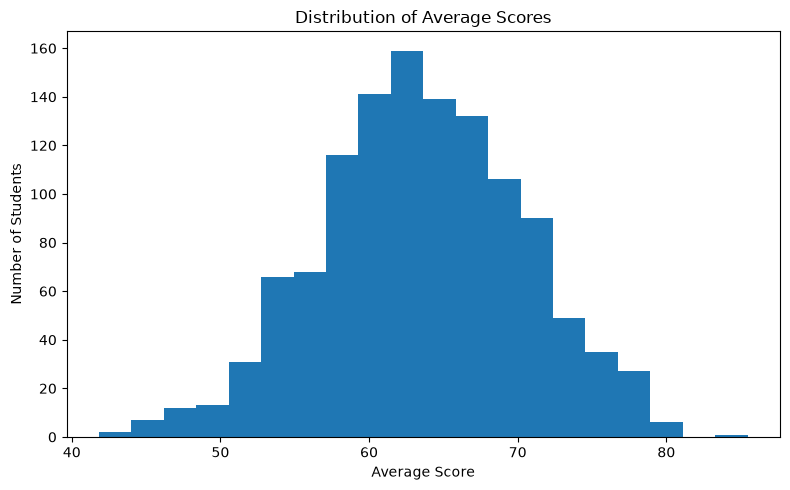

In [9]:
ax = df["average_score"].plot(
    kind="hist",
    bins=20,
    figsize=(8, 5),
    title="Distribution of Average Scores"
)

ax.set_xlabel("Average Score")
ax.set_ylabel("Number of Students")

plt.tight_layout()
plt.savefig("figures/average_score_histogram.png", dpi=150)
plt.show()

## Figure 2 — Study-hours box plot

The box plot is used to inspect the centre, spread and potential outliers in weekly study hours.

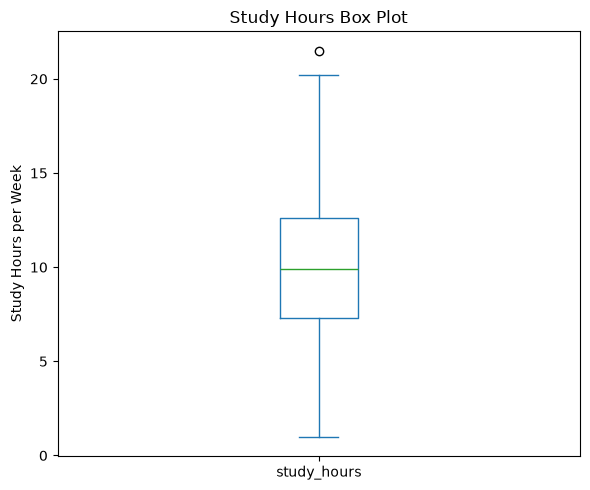

In [10]:
ax = df["study_hours"].plot(
    kind="box",
    figsize=(6, 5),
    title="Study Hours Box Plot"
)

ax.set_ylabel("Study Hours per Week")

plt.tight_layout()
plt.savefig("figures/study_hours_boxplot.png", dpi=150)
plt.show()

# 3. Bivariate

This section examines relationships between pairs of variables and compares average performance across important learner groups.

In [11]:
correlation_columns = [
    "attendance",
    "study_hours",
    "math_score",
    "english_score",
    "science_score",
    "average_score"
]

correlation_matrix = df[correlation_columns].corr()

display(correlation_matrix.round(3))

,attendance,study_hours,math_score,english_score,science_score,average_score
attendance,1.000,0.102,0.214,0.173,0.227,0.281
study_hours,0.102,1.000,0.498,0.432,0.525,0.666
math_score,0.214,0.498,1.000,0.273,0.356,0.752
english_score,0.173,0.432,0.273,1.000,0.264,0.691
science_score,0.227,0.525,0.356,0.264,1.000,0.744
average_score,0.281,0.666,0.752,0.691,0.744,1.000


In [12]:
average_correlations = (
    correlation_matrix["average_score"]
    .drop("average_score")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Relationships with average_score ranked by absolute correlation:")
display(average_correlations.round(3))

Relationships with average_score ranked by absolute correlation:


math_score       0.752
science_score    0.744
english_score    0.691
study_hours      0.666
attendance       0.281
Name: average_score, dtype: float64

In [13]:
top_three = average_correlations.head(3)

print("Three strongest relationships with average_score:")
for variable, correlation in top_three.items():
    print(f"{variable}: r = {correlation:.3f}")

Three strongest relationships with average_score:
math_score: r = 0.752
science_score: r = 0.744
english_score: r = 0.691


In [14]:
gender_scores = (
    df.groupby("gender", observed=True)["average_score"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(gender_scores.round(2))

,count,mean,median
gender,,,
Female,626,63.68,63.53
Male,574,63.42,63.33


In [15]:
school_scores = (
    df.groupby("school_type", observed=True)["average_score"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(school_scores.round(2))

,count,mean,median
school_type,,,
Private,362,66.34,66.45
Public,838,62.36,62.27


In [16]:
school_gap = (
    df.groupby("school_type", observed=True)["average_score"].mean().max()
    - df.groupby("school_type", observed=True)["average_score"].mean().min()
)

print(f"School-type average-score gap: {school_gap:.2f} points")

School-type average-score gap: 3.98 points


In [17]:
county_scores = (
    df.groupby("county", observed=True)["average_score"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

display(county_scores.round(2))

,count,mean,median
county,,,
Kisumu,213,64.08,63.43
Laikipia,172,63.74,63.75
Nakuru,262,63.73,64.03
Mombasa,254,63.36,63.43
Nairobi,299,63.11,63.07


In [18]:
county_performance = pd.crosstab(
    df["county"],
    df["performance_band"],
    normalize="index"
).mul(100)

display(county_performance.round(2))

performance_band,At Risk,Meeting,Exceeding
county,,,
Kisumu,31.46,60.56,7.98
Laikipia,28.49,69.19,2.33
Mombasa,28.74,65.75,5.51
Nairobi,33.11,61.87,5.02
Nakuru,28.24,67.18,4.58


In [19]:
at_risk_by_county = (
    county_performance["At Risk"]
    .sort_values(ascending=False)
)

print("County ranked by At Risk share:")
display(at_risk_by_county.round(2))

highest_risk_county = at_risk_by_county.idxmax()
highest_risk_share = at_risk_by_county.max()

print(
    f"County with the highest At Risk share: "
    f"{highest_risk_county} ({highest_risk_share:.2f}%)"
)

County ranked by At Risk share:


county
Nairobi     33.11
Kisumu      31.46
Mombasa     28.74
Laikipia    28.49
Nakuru      28.24
Name: At Risk, dtype: float64

County with the highest At Risk share: Nairobi (33.11%)


## Figure 3 — Average score by school type

The bar chart compares mean average scores between public and private schools.

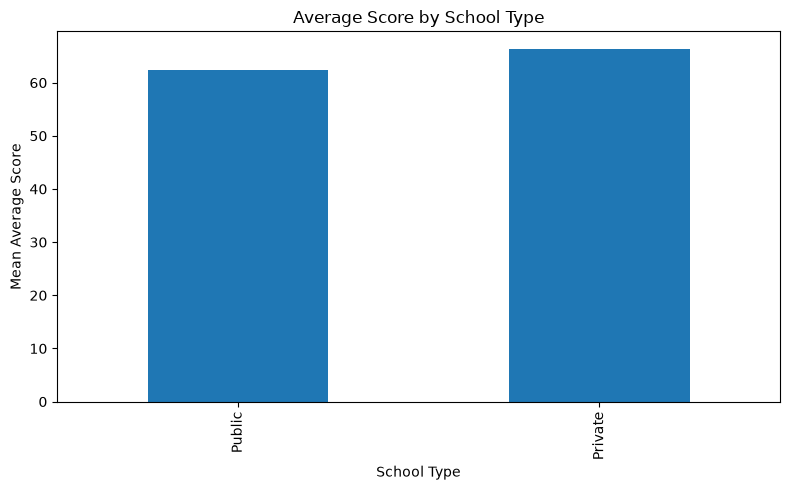

In [20]:
ax = (
    df.groupby("school_type", observed=True)["average_score"]
    .mean()
    .sort_values()
    .plot(
        kind="bar",
        figsize=(8, 5),
        title="Average Score by School Type"
    )
)

ax.set_xlabel("School Type")
ax.set_ylabel("Mean Average Score")

plt.tight_layout()
plt.savefig("figures/school_type_bar.png", dpi=150)
plt.show()

# 4. Multivariate

This section examines whether the school-type performance gap persists after considering attendance and study-hour levels.

In [21]:
df["attendance_band"] = pd.cut(
    df["attendance"],
    bins=[0, 70, 85, 100],
    labels=["Low (<70%)", "Medium (70–84%)", "High (85%+)"],
    right=False
)

display(
    df[
        ["attendance", "attendance_band"]
    ].head()
)

,attendance,attendance_band
0,62.1,Low (<70%)
1,91.1,High (85%+)
2,85.0,High (85%+)
3,86.5,High (85%+)
4,75.4,Medium (70–84%)


In [22]:
attendance_pivot = pd.pivot_table(
    df,
    values="average_score",
    index="attendance_band",
    columns="school_type",
    aggfunc="mean",
    observed=True
)

display(attendance_pivot.round(2))

school_type,Private,Public
attendance_band,,
Low (<70%),63.81,59.08
Medium (70–84%),65.50,61.57
High (85%+),67.82,64.07


In [23]:
attendance_pivot["school_type_gap"] = (
    attendance_pivot.max(axis=1)
    - attendance_pivot.min(axis=1)
)

display(attendance_pivot.round(2))

school_type,Private,Public,school_type_gap
attendance_band,,,
Low (<70%),63.81,59.08,4.73
Medium (70–84%),65.50,61.57,3.93
High (85%+),67.82,64.07,3.76


In [24]:
df["study_hours_quartile"] = pd.qcut(
    df["study_hours"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ]
)

display(
    df[
        ["study_hours", "study_hours_quartile"]
    ].head(10)
)

,study_hours,study_hours_quartile
0,14.3,Q4 - Highest
1,7.8,Q2
2,13.0,Q4 - Highest
3,7.0,Q1 - Lowest
4,14.5,Q4 - Highest
5,7.3,Q1 - Lowest
6,4.0,Q1 - Lowest
7,8.3,Q2
8,9.2,Q2
9,15.3,Q4 - Highest


In [25]:
study_pivot = pd.pivot_table(
    df,
    values="average_score",
    index="study_hours_quartile",
    columns="school_type",
    aggfunc="mean",
    observed=True
)

display(study_pivot.round(2))

school_type,Private,Public
study_hours_quartile,,
Q1 - Lowest,61.43,56.26
Q2,64.34,60.67
Q3,68.95,64.24
Q4 - Highest,71.07,68.46


In [26]:
study_pivot["school_type_gap"] = (
    study_pivot.max(axis=1)
    - study_pivot.min(axis=1)
)

display(study_pivot.round(2))

school_type,Private,Public,school_type_gap
study_hours_quartile,,,
Q1 - Lowest,61.43,56.26,5.17
Q2,64.34,60.67,3.67
Q3,68.95,64.24,4.71
Q4 - Highest,71.07,68.46,2.62


# 5. Hypotheses

The analysis tests the following practical hypotheses:

1. Learners who study more hours tend to have higher average scores.
2. Higher attendance is associated with higher average scores.
3. School type is associated with differences in average scores.
4. The school-type performance gap may change across attendance levels.
5. The school-type performance gap may change across study-hour quartiles.

These are associations observed in the data and should not be interpreted automatically as causal effects.

## Study hours and average score trend

Because the dataset contains no dates, a trend line is fitted between study hours and average score using `np.polyfit`.

In [28]:
x = df["study_hours"].to_numpy()
y = df["average_score"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)

predicted = slope * x + intercept

ss_res = np.sum((y - predicted) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R²: {r_squared:.4f}")

Slope: 1.1907
Intercept: 51.6654
R²: 0.4434


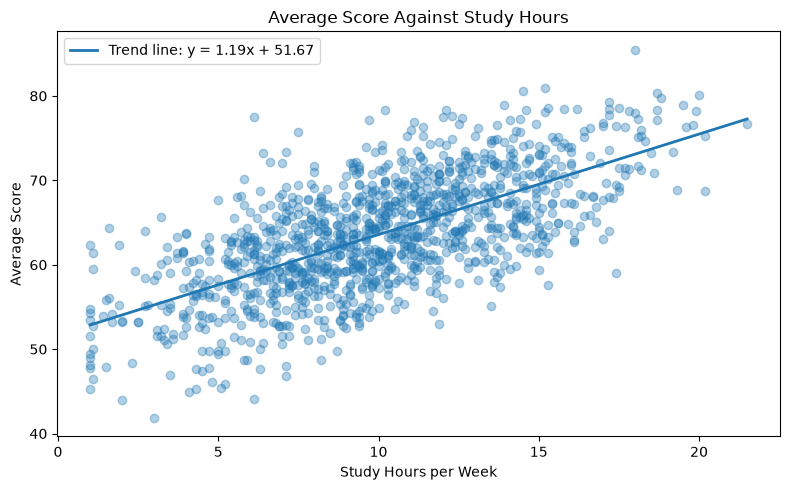

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["study_hours"],
    df["average_score"],
    alpha=0.35
)

x_line = np.linspace(
    df["study_hours"].min(),
    df["study_hours"].max(),
    100
)

y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label=f"Trend line: y = {slope:.2f}x + {intercept:.2f}"
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Average Score")
plt.title("Average Score Against Study Hours")
plt.legend()

plt.tight_layout()
plt.savefig("figures/study_hours_trend.png", dpi=150)
plt.show()

### Interpretation of the slope

The slope indicates the expected change in average score associated with a one-hour increase in weekly study hours. A positive slope indicates that higher study hours are associated with higher average scores.

### Limitation

The trend line describes an association in this dataset and should not be used to claim that increasing study hours alone will cause a specific improvement in scores, because other factors may influence performance and the analysis is observational.

**R-squared:** The fitted trend line explains the proportion of variation in average_score associated with study_hours.

In [30]:
overall_average = df["average_score"].mean()

top_correlation_variable = top_three.index[0]
top_correlation_value = top_three.iloc[0]

best_school_type = school_scores["mean"].idxmax()
best_school_score = school_scores.loc[best_school_type, "mean"]

worst_school_type = school_scores["mean"].idxmin()
worst_school_score = school_scores.loc[worst_school_type, "mean"]

best_county = county_scores["mean"].idxmax()
best_county_score = county_scores.loc[best_county, "mean"]

print("Overall average score:", round(overall_average, 2))
print(
    f"Strongest relationship with average_score: "
    f"{top_correlation_variable} (r={top_correlation_value:.3f})"
)
print(
    f"Highest-performing school type: "
    f"{best_school_type} ({best_school_score:.2f})"
)
print(
    f"Lowest-performing school type: "
    f"{worst_school_type} ({worst_school_score:.2f})"
)
print(
    f"Highest-performing county: "
    f"{best_county} ({best_county_score:.2f})"
)
print(
    f"Highest At Risk county: "
    f"{highest_risk_county} ({highest_risk_share:.2f}%)"
)

Overall average score: 63.56
Strongest relationship with average_score: math_score (r=0.752)
Highest-performing school type: Private (66.34)
Lowest-performing school type: Public (62.36)
Highest-performing county: Kisumu (64.08)
Highest At Risk county: Nairobi (33.11%)


# Findings

### Finding 1 — Overall learner performance

The overall average score provides a baseline for the academic performance of the 1,200 learners. The performance-band distribution also shows the proportion of learners who are At Risk, Meeting expectations and Exceeding expectations.

### Finding 2 — Strongest relationships with performance

The correlation analysis identifies the three numerical variables most strongly associated with average_score. These relationships indicate which measurable learner characteristics are most closely related to academic performance in this dataset.

### Finding 3 — School-type differences

Average scores differ between public and private schools. The size of this difference provides evidence on whether school type should be considered when targeting learner-support interventions.

### Finding 4 — County differences and risk concentration

Average performance varies across counties. Importantly, the county with the highest share of At Risk learners provides a potential geographic priority for learner-support resources.

### Finding 5 — School-type gap across learner conditions

The attendance-band and study-hour-quartile pivot tables show whether the school-type gap remains visible after comparing learners with similar attendance or study-hour levels.

**Important:** These findings describe associations and differences in the observed data. They do not establish causation.

# Recommendations

### Recommendation 1 — Target support using county-level risk

Prioritise learner-support resources toward the county with the highest observed At Risk share, while validating the result with local education officers before allocating the final programme budget. Within the priority county, identify schools and learner groups with particularly high concentrations of At Risk learners.

### Recommendation 2 — Combine academic support with attendance and study support

Use attendance and study-hour patterns to identify learners who may benefit from targeted academic support, study-skills programmes, mentoring and attendance interventions. The programme should focus on learners showing multiple risk indicators rather than treating any single variable as proof of poor future performance.

# Limitations

This analysis is exploratory and observational. Correlations and trend lines show associations rather than causation. The dataset contains no dates, so it cannot establish changes in performance over time. Study hours and attendance may not capture the quality of studying or the reasons behind attendance patterns. County and school-type comparisons may also reflect other factors that are not included in the dataset. Therefore, the findings should support targeting and further investigation rather than be treated as definitive evidence that one factor causes better or worse academic performance.

# Conclusion

The EDA provides evidence on learner performance, risk concentration and factors associated with average scores. The analysis combines descriptive statistics, correlations, group comparisons, pivot tables and a study-hours trend line to support evidence-based programme targeting.

The results should be used as a starting point for targeted learner-support planning, followed by local validation and more detailed analysis where necessary.

In [31]:
import os

required_figures = [
    "figures/average_score_histogram.png",
    "figures/study_hours_boxplot.png",
    "figures/school_type_bar.png",
    "figures/study_hours_trend.png"
]

for figure in required_figures:
    print(
        f"{figure}:",
        "EXISTS" if os.path.exists(figure) else "MISSING"
    )

figures/average_score_histogram.png: EXISTS
figures/study_hours_boxplot.png: EXISTS
figures/school_type_bar.png: EXISTS
figures/study_hours_trend.png: EXISTS
